In [0]:
# Gold path fra pipeline
gold_adls = "abfss://gold@sdfgsdfgs456ghh.dfs.core.windows.net/earthquake_events_gold/"

# Les inn som Spark DataFrame
df_gold = spark.read.parquet(gold_adls)

# Sjekk de første radene
df_gold.show(5)

# Sjekk schema
df_gold.printSchema()

+-------------+-----------------+----------------+---------+--------------------+--------------------+---+----+-------+--------------------+--------------------+------------+---------+
|           id|        longitude|        latitude|elevation|               title|   place_description|sig| mag|magType|                time|             updated|country_code|sig_class|
+-------------+-----------------+----------------+---------+--------------------+--------------------+---+----+-------+--------------------+--------------------+------------+---------+
|   pr71508438|-66.7823333333333|18.0391666666667|     15.6|M 2.1 - 2 km NNE ...|2 km NNE of Guaya...| 66|2.07|     md|2026-02-21 23:55:...|2026-02-22 00:33:...|          PR|      Low|
|   us6000sapq|         166.4871|        -46.2323|   42.088|M 4.9 - 118 km W ...|118 km W of River...|370| 4.9|    mww|2026-02-21 23:55:...|2026-02-22 00:53:...|          NZ| Moderate|
|aka2026drlmyc|         -154.944|          57.291|     53.4|M 2.1 - 42 km S

In [0]:
df_gold.groupBy("country_code").count().orderBy("count", ascending=False).show(10)

+------------+-----+
|country_code|count|
+------------+-----+
|          US|   25|
|          AF|    2|
|          VG|    1|
|          NZ|    1|
|          PR|    1|
+------------+-----+



In [0]:
df_gold.groupBy("sig_class").count().show()

+---------+-----+
|sig_class|count|
+---------+-----+
|      Low|   26|
| Moderate|    4|
+---------+-----+



In [0]:
from pyspark.sql.functions import to_date
df_gold.groupBy(to_date("time").alias("date"), "country_code").count().orderBy("date").show()

+----------+------------+-----+
|      date|country_code|count|
+----------+------------+-----+
|2026-02-14|          AF|    2|
|2026-02-14|          US|   18|
|2026-02-21|          NZ|    1|
|2026-02-21|          US|    7|
|2026-02-21|          PR|    1|
|2026-02-21|          VG|    1|
+----------+------------+-----+



In [0]:
display(df_gold.select("mag", "sig_class"))

mag,sig_class
2.07,Low
4.9,Moderate
2.1,Low
3.37,Moderate
2.3,Low
1.9,Low
0.71,Low
1.7,Low
1.19,Low
1.62,Low


In [0]:
# Antall jordskjelv per land
country_counts = df_gold.groupBy("country_code").count().orderBy("count", ascending=False)
display(country_counts)

country_code,count
US,25
AF,2
VG,1
NZ,1
PR,1


In [0]:
sig_counts = df_gold.groupBy("sig_class").count()
display(sig_counts)

sig_class,count
Low,26
Moderate,4


In [0]:
from pyspark.sql.functions import to_date

time_counts = df_gold.groupBy(to_date("time").alias("date")).count().orderBy("date")
display(time_counts)

date,count
2026-02-14,20
2026-02-21,10


In [0]:
time_country_counts = df_gold.groupBy(
    to_date("time").alias("date"), "country_code"
).count().orderBy("date")
display(time_country_counts)

date,country_code,count
2026-02-14,AF,2
2026-02-14,US,18
2026-02-21,NZ,1
2026-02-21,US,7
2026-02-21,PR,1
2026-02-21,VG,1


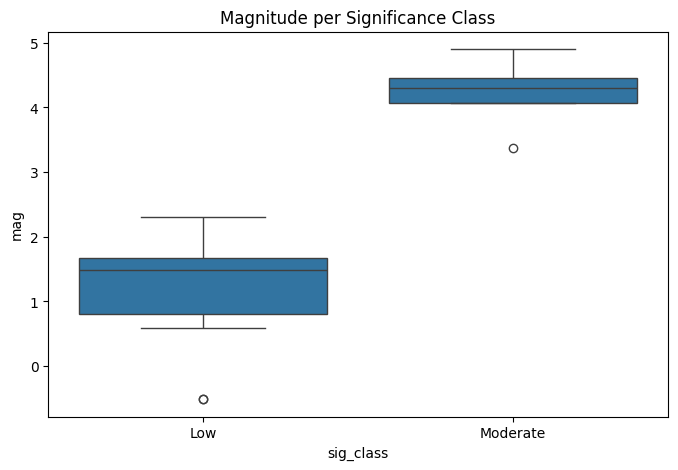

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Konverter til Pandas for plotting
df_pd = df_gold.toPandas()

plt.figure(figsize=(8,5))
sns.boxplot(x="sig_class", y="mag", data=df_pd)
plt.title("Magnitude per Significance Class")
plt.show()

In [0]:
import plotly.express as px

# Legg til en liten konstant slik at alle størrelser blir positive
df_pd['mag_size'] = df_pd['mag'] + 1  # nå blir -0.51 -> 0.49

fig = px.scatter(
    df_pd,
    x='longitude',
    y='latitude',
    size='mag_size',  # bruker den positive verdien
    color='sig_class',
    hover_data=['mag','country_code'],
    title='Earthquake Locations (Gold)',
    size_max=40
)
fig.show()

In [0]:
df_gold.select("mag", "sig_class", "country_code", "longitude", "latitude").show(20)

+-----+---------+------------+-----------------+----------------+
|  mag|sig_class|country_code|        longitude|        latitude|
+-----+---------+------------+-----------------+----------------+
| 2.07|      Low|          PR|-66.7823333333333|18.0391666666667|
|  4.9| Moderate|          NZ|         166.4871|        -46.2323|
|  2.1|      Low|          US|         -154.944|          57.291|
| 3.37| Moderate|          VG|         -64.1165|19.2073333333333|
|  2.3|      Low|          US|         -152.377|          60.193|
|  1.9|      Low|          US|         -151.756|          60.778|
| 0.71|      Low|          US|-116.250666666667|33.3403333333333|
|  1.7|      Low|          US|         -146.867|          61.251|
| 1.19|      Low|          US|-118.294833333333|          35.485|
| 1.62|      Low|          US|-120.887496948242|36.3153343200684|
| 1.68|      Low|          US|     -98.39433333|          35.862|
|  1.5|      Low|          US|         -151.209|          62.557|
| 0.59|   

In [0]:
df_pd.shape

(30, 14)